In [36]:
import pandas as pd
import glob
import os
from datetime import datetime

caminho_monitoramento = r'C:\Users\Luca\Documents\git hub\Projetos em grupo\PI-Monitoramento_frutas\data\monitoramento'

caminhos = glob.glob(os.path.join(caminho_monitoramento, "*.csv"))
lista_dfs = []

print(f"--- Iniciando Carregamento em: {caminho_monitoramento} ---")

for f in caminhos:
    temp_df = pd.read_csv(f)
    

    temp_df.columns = temp_df.columns.str.strip().str.lower()
    
    temp_df['origem_arquivo'] = os.path.basename(f)
    
    lista_dfs.append(temp_df)
    print(f"Arquivo carregado: {os.path.basename(f)} | Colunas: {len(temp_df.columns)}")


df = pd.concat(lista_dfs, ignore_index=True)


df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed')

print(f"--- Unificação concluída: {len(df)} linhas totais ---")


nome_mestre = f"dataset_mestre_unificado_{datetime.now().strftime('%d-%m-%Y_%H-%M')}.csv"
df.to_csv(nome_mestre, index=False, encoding='utf-8-sig', sep=';')
print(f" '{nome_mestre}' gerado automaticamente.")

del lista_dfs

--- Iniciando Carregamento em: C:\Users\Luca\Documents\git hub\Projetos em grupo\PI-Monitoramento_frutas\data\monitoramento ---
Arquivo carregado: ambiente.csv | Colunas: 11
Arquivo carregado: banana.csv | Colunas: 11
Arquivo carregado: banana_terra.csv | Colunas: 11
Arquivo carregado: p_ambiente.csv | Colunas: 7
Arquivo carregado: p_banana.csv | Colunas: 7
Arquivo carregado: tomate.csv | Colunas: 11
--- Unificação concluída: 1396 linhas totais ---
 'dataset_mestre_unificado_01-03-2026_20-39.csv' gerado automaticamente.


In [37]:
import os
from datetime import datetime

pasta_graficos = r'C:\Users\Luca\Documents\git hub\Projetos em grupo\PI-Monitoramento_frutas\data\gráficos'
if not os.path.exists(pasta_graficos):
    os.makedirs(pasta_graficos)

def salvar_grafico(titulo):
    data_hora = datetime.now().strftime("%d-%m-%Y_%H-%M")
    nome_arquivo = f"{titulo}_{data_hora}.png"
    caminho_completo = os.path.join(pasta_graficos, nome_arquivo)
    plt.savefig(caminho_completo, bbox_inches='tight')
    print(f" Gráfico salvo: {nome_arquivo}")

# Dados ausentes


In [38]:
print(df.isnull().sum())

# Para sensores: Imputar mediana para não enviesar com zeros.
df['temperatura'] = df['temperatura'].fillna(df['temperatura'].median())
df['umidade_ar'] = df['umidade_ar'].fillna(df['umidade_ar'].median())
df['mq3_raw'] = df['mq3_raw'].fillna(df['mq3_raw'].median())

# Para o Target (Validade):
# Não "inventar" a validade onde ela não existe.
# Mantem apenas as linhas que têm rótulo (label).
df = df.dropna(subset=['validade'])
print(f"Dataset filtrado para treino: {len(df)} linhas.")

timestamp             0
tipofruta             0
lote                686
temperatura           0
umidade_ar            0
mq3_raw               0
mq3_tensao            0
estado_previsto     686
estado_real         686
validade           1263
origem_arquivo        0
dtype: int64
Dataset filtrado para treino: 133 linhas.


# Limpeza de dados

In [39]:
# Substituir valores ausentes remanescentes em colunas categóricas
df['lote'] = df['lote'].fillna('desconhecido')

# Remover mq3_tensao: Já provamos que é redundante ao mq3_raw (Colinearidade)
if 'mq3_tensao' in df.columns:
    df = df.drop(columns=['mq3_tensao'])

# Limpeza de strings (remover espaços extras que podem vir do Arduino)
df['tipofruta'] = df['tipofruta'].str.strip()

# Exploração de dados

 Gráfico salvo: matriz_pares_frutas_01-03-2026_20-40.png


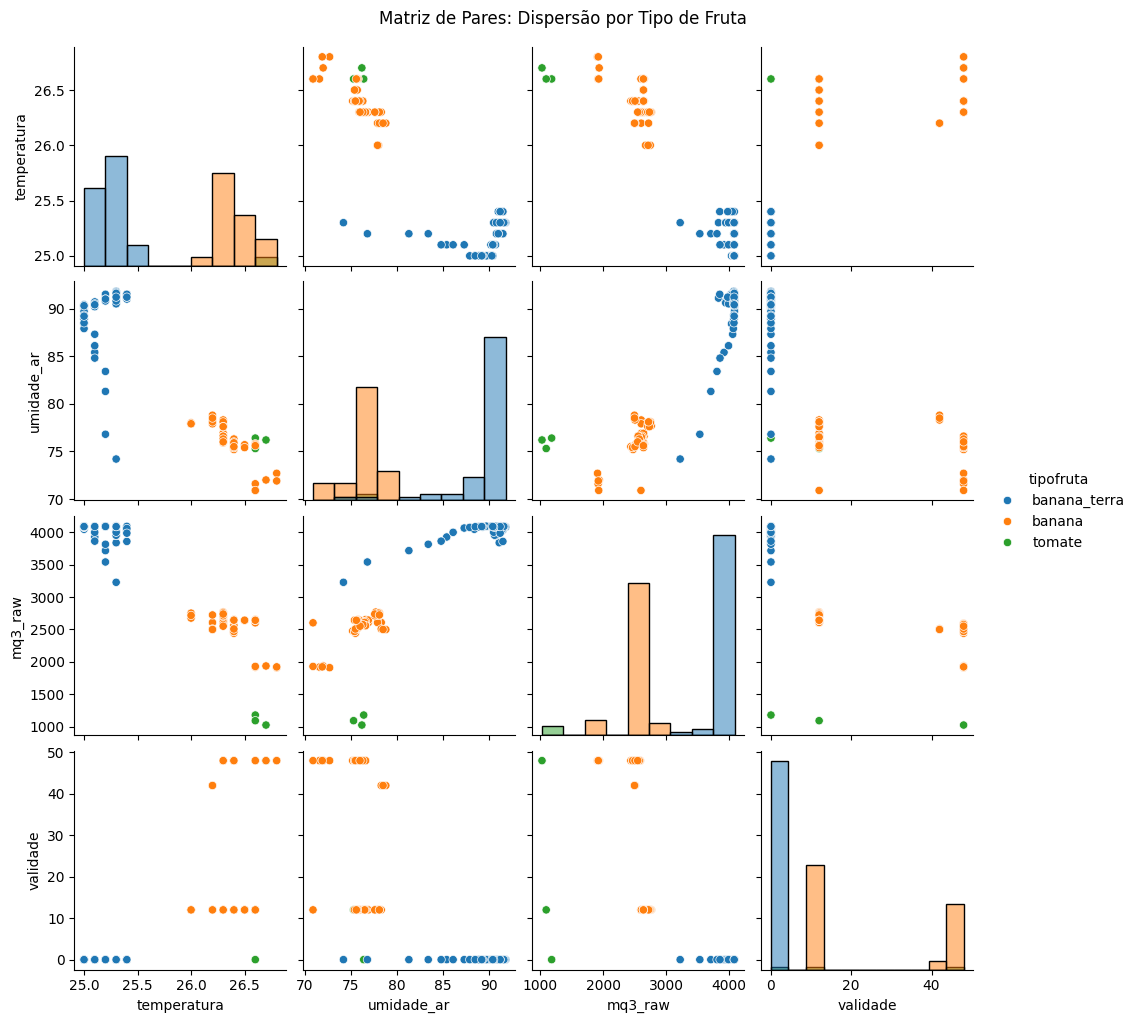

In [40]:
g = sns.pairplot(df.sample(min(len(df), 500)), hue='tipofruta', diag_kind='hist')
g.fig.suptitle("Matriz de Pares: Dispersão por Tipo de Fruta", y=1.02)
salvar_grafico("matriz_pares_frutas")
plt.show()

 Gráfico salvo: correlacao_bruta_01-03-2026_20-40.png


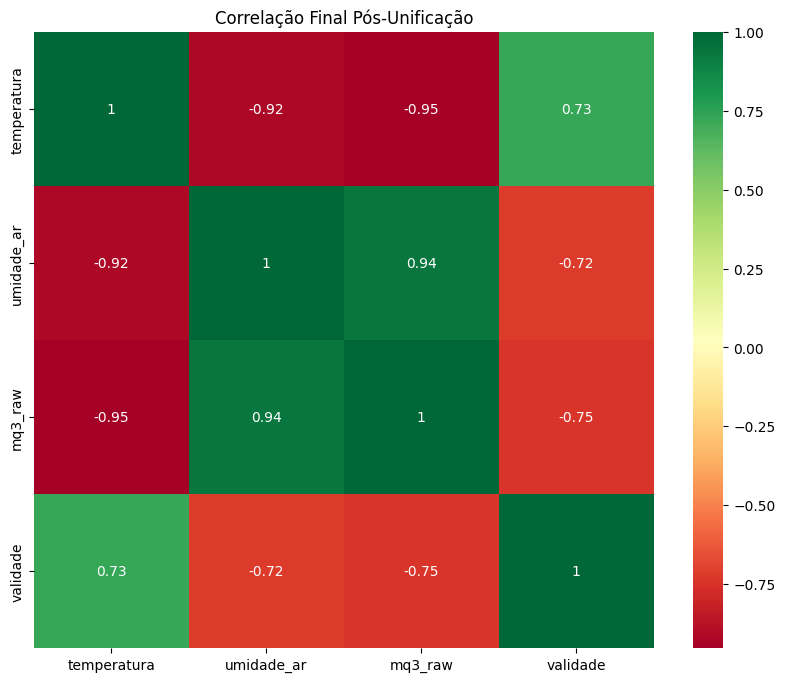

 Gráfico salvo: boxplot_mq3_frutas_01-03-2026_20-40.png


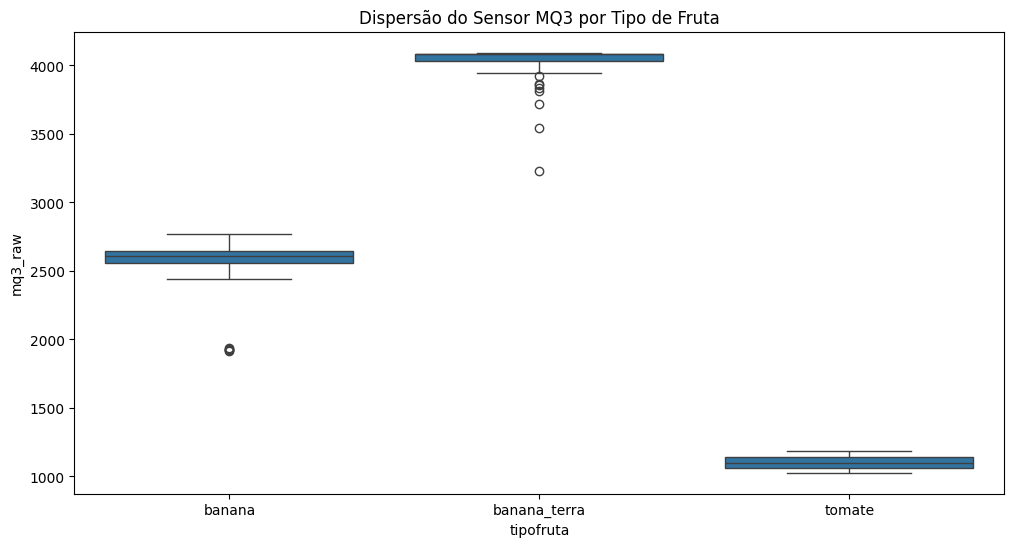

In [41]:
# Matriz de Correlação
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='RdYlGn')
plt.title("Correlação Final Pós-Unificação")
salvar_grafico("correlacao_bruta")
plt.show()

# Boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(x='tipofruta', y='mq3_raw', data=df)
plt.title("Dispersão do Sensor MQ3 por Tipo de Fruta")
salvar_grafico("boxplot_mq3_frutas")
plt.show()

 Gráfico salvo: coordenadas_paralelas_01-03-2026_20-40.png


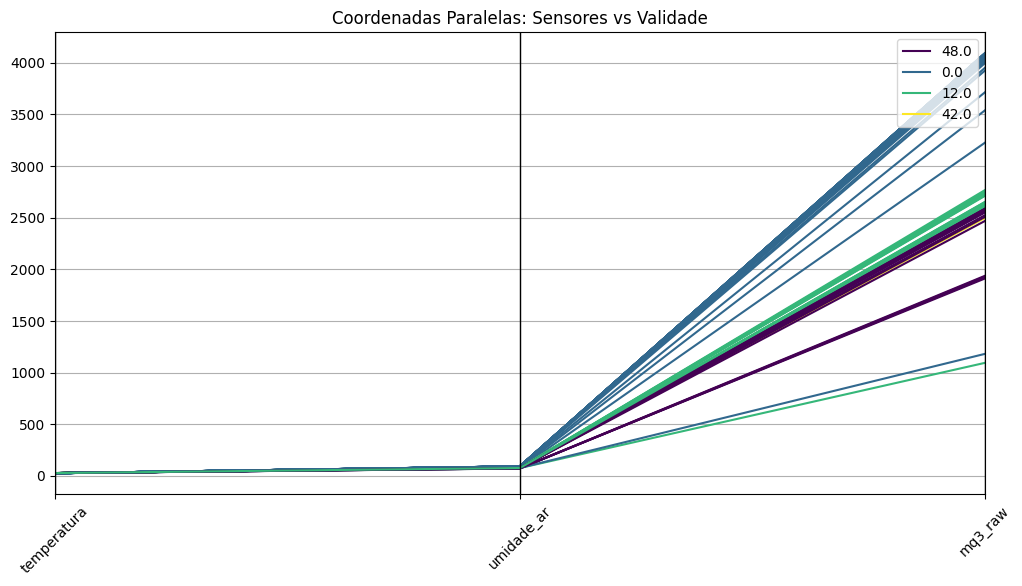

In [42]:
from pandas.plotting import parallel_coordinates
import matplotlib.pyplot as plt


df_viz = df.copy()
if len(df_viz) > 100:
    df_viz = df_viz.sample(100)

df_viz['validade_str'] = df_viz['validade'].astype(str)

plt.figure(figsize=(12, 6))
parallel_coordinates(df_viz[['temperatura', 'umidade_ar', 'mq3_raw', 'validade_str']], 'validade_str', colormap='viridis')

plt.title("Coordenadas Paralelas: Sensores vs Validade")
plt.xticks(rotation=45)
salvar_grafico("coordenadas_paralelas")
plt.show()

# Pré - processamento

In [43]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Converter timestamp com formato misto 
df['timestamp'] = pd.to_datetime(df['timestamp'], format='mixed')

# 2. Extrair atributos numéricos
df_proc = df.copy()
df_proc['hora'] = df['timestamp'].dt.hour
df_proc['dia_semana'] = df['timestamp'].dt.dayofweek

# Remove o timestamp original
df_proc = df_proc.drop(columns=['timestamp'], errors='ignore')

In [44]:
# A. Codifica Rótulo (Label Encoder) para tipofruta
le = LabelEncoder()
if 'tipofruta' in df_proc.columns:
    df_proc['tipofruta_n'] = le.fit_transform(df_proc['tipofruta'].astype(str))

# B. Variáveis Dummy para Lote
if 'lote' in df_proc.columns:
    df_proc = pd.get_dummies(df_proc, columns=['lote'], prefix='lote', drop_first=True)

# C. LIMPEZA FINAL: Removendo colunas de texto/metadados
# errors='ignore' para evitar o KeyError que você recebeu
colunas_para_remover = ['tipofruta', 'estado_previsto', 'estado_real', 'origem_arquivo', 'mq3_tensao']
df_proc = df_proc.drop(columns=colunas_para_remover, errors='ignore')

print("Limpeza concluída. Colunas atuais:", df_proc.columns.tolist())

Limpeza concluída. Colunas atuais: ['temperatura', 'umidade_ar', 'mq3_raw', 'validade', 'hora', 'dia_semana', 'tipofruta_n', 'lote_lote_Madrugada', 'lote_lote_Madrugada_2', 'lote_lote_Tarde_1', 'lote_lote_[teste_banana_passada]']


In [45]:
# Escalonamento para preparar para a placa de vídeo
scaler = StandardScaler()
cols_sensores = ['temperatura', 'umidade_ar', 'mq3_raw']

# Certifica que as colunas existem antes de escalar
cols_presentes = [c for c in cols_sensores if c in df_proc.columns]
df_proc[cols_presentes] = scaler.fit_transform(df_proc[cols_presentes])

print("Check de Pré-processamento: OK")

Check de Pré-processamento: OK


# Seleção de atributos - colunas

 Gráfico salvo: correlacao_processada_01-03-2026_20-40.png


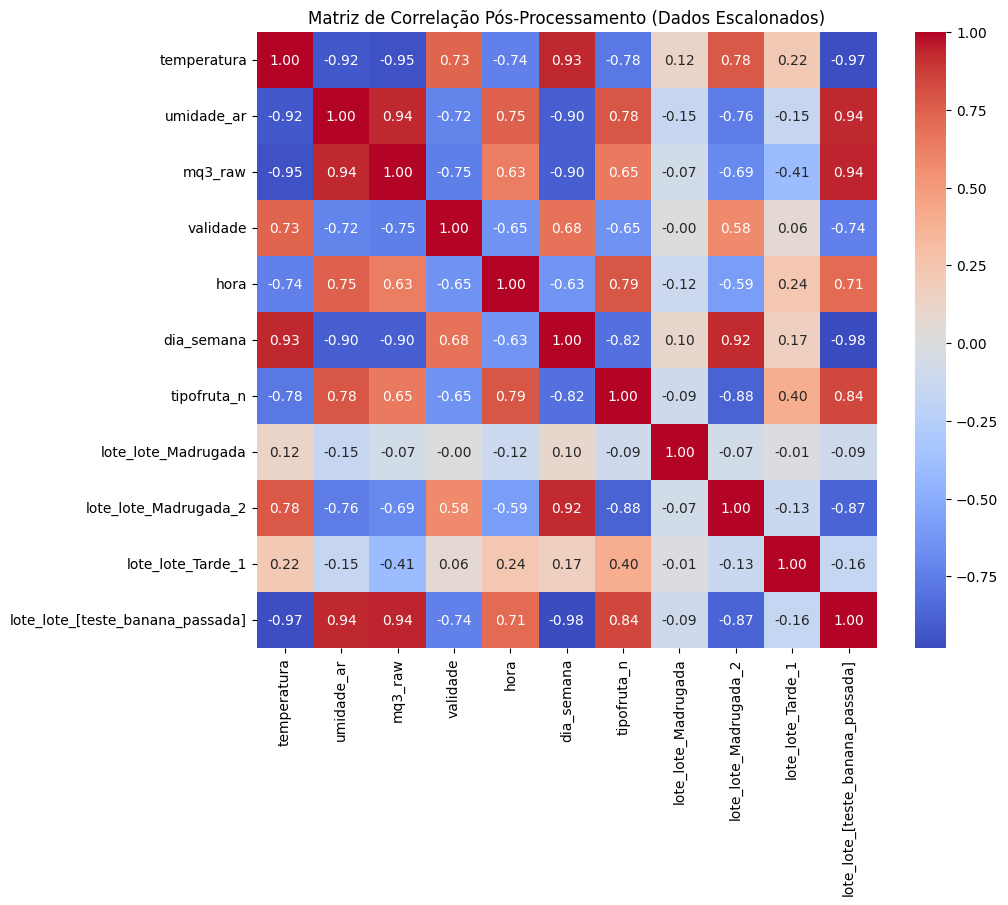

In [46]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_proc.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlação Pós-Processamento (Dados Escalonados)")
salvar_grafico("correlacao_processada")
plt.show()

In [47]:
from sklearn.feature_selection import mutual_info_regression

# Definindo X (features) e y (target)
X = df_proc.drop(columns=['validade'])
y = df_proc['validade']

mi = mutual_info_regression(X, y, random_state=42)
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)

print("--- Ranking de Importância (Mutual Information) ---")
print(mi_series)

--- Ranking de Importância (Mutual Information) ---
mq3_raw                             0.934942
temperatura                         0.775171
umidade_ar                          0.711068
lote_lote_[teste_banana_passada]    0.704088
hora                                0.701562
dia_semana                          0.641573
tipofruta_n                         0.579811
lote_lote_Madrugada_2               0.559958
lote_lote_Madrugada                 0.000000
lote_lote_Tarde_1                   0.000000
dtype: float64


In [48]:
from sklearn.linear_model import LassoCV

# O LassoCV encontra o melhor parâmetro de penalidade sozinho
lasso = LassoCV(cv=5).fit(X, y)
atributos_mantidos = X.columns[lasso.coef_ != 0].tolist()

print(f"Atributos selecionados pelo LASSO: {atributos_mantidos}")

Atributos selecionados pelo LASSO: ['mq3_raw', 'hora']


c:\Users\Luca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.605e+00, tolerance: 3.652e+00
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Luca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.020e+01, tolerance: 3.652e+00
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\Luca\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check 

In [49]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor

selector = RFE(RandomForestRegressor(n_estimators=10, random_state=42), n_features_to_select=5)
selector = selector.fit(X, y)

ranking = pd.Series(selector.ranking_, index=X.columns).sort_values()
print("--- Ranking RFE (1 é o melhor) ---")
print(ranking)

--- Ranking RFE (1 é o melhor) ---
temperatura                         1
mq3_raw                             1
hora                                1
tipofruta_n                         1
lote_lote_Tarde_1                   1
lote_lote_[teste_banana_passada]    2
umidade_ar                          3
lote_lote_Madrugada_2               4
dia_semana                          5
lote_lote_Madrugada                 6
dtype: int64


# Classes desbalanceadas

In [50]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

# X e y já definidos no passo anterior
X_final = df_proc.drop(columns=['validade'])
y_final = df_proc['validade']

#k_neighbors deve ser menor que o número de amostras da menor classe (3 - 1 = 2)
over = SMOTE(sampling_strategy='auto', k_neighbors=2, random_state=42)
under = RandomUnderSampler(sampling_strategy='auto', random_state=42)

pipeline = Pipeline(steps=[('o', over), ('u', under)])

try:
    X_resampled, y_resampled = pipeline.fit_resample(X_final, y_final)
    print("--- Nova Distribuição Pós-SMOTE ---")
    print(pd.Series(y_resampled).value_counts())
except Exception as e:
    print(f"Erro persistente: {e}")

--- Nova Distribuição Pós-SMOTE ---
validade
0.0     71
12.0    71
42.0    71
48.0    71
Name: count, dtype: int64


In [51]:
df_proc['validade_binaria'] = df_proc['validade'].apply(lambda x: 1 if x == 48.0 else 0)
print("Distribuição Binária:\n", df_proc['validade_binaria'].value_counts())

Distribuição Binária:
 validade_binaria
0    110
1     23
Name: count, dtype: int64


# Treinamento e Avaliação

In [52]:
from sklearn.model_selection import train_test_split

# Usando o dataset balanceado pelo SMOTE
X = X_resampled
y = y_resampled

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")

Treino: 227 amostras | Teste: 57 amostras


In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Criando e treinando o modelo
modelo = RandomForestClassifier(n_estimators=100, random_state=42)
modelo.fit(X_train, y_train)

# Fazendo previsões
y_pred = modelo.predict(X_test)

 Gráfico salvo: matriz_confusao_ia_01-03-2026_20-40.png


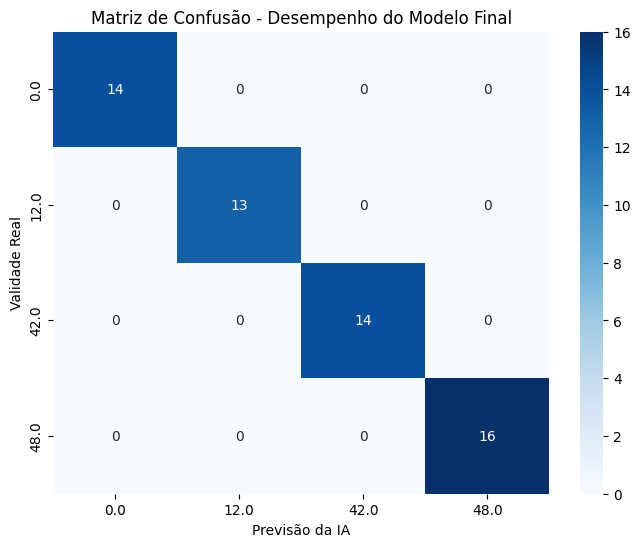

In [54]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

#  Gera a matriz comparando o real (y_test) com o que a IA previu (y_pred)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=modelo.classes_, yticklabels=modelo.classes_)

plt.xlabel('Previsão da IA')
plt.ylabel('Validade Real')
plt.title('Matriz de Confusão - Desempenho do Modelo Final')
salvar_grafico("matriz_confusao_ia")
plt.show()

# Deployment

In [58]:
import joblib
import os
from datetime import datetime

pasta_modelos = r'C:\Users\Luca\Documents\git hub\Projetos em grupo\PI-Monitoramento_frutas\modelos'

if not os.path.exists(pasta_modelos):
    os.makedirs(pasta_modelos)

data_hora = datetime.now().strftime("%d-%m-%Y_%H-%M")
nome_modelo = f"modelo_frutas_{data_hora}.pkl"
caminho_salvamento = os.path.join(pasta_modelos, nome_modelo)

artefatos = {
    'modelo': modelo,
    'scaler': scaler,
    'label_encoder': le,
    'features': X.columns.tolist(),
    'data_treinamento': data_hora
}

try:
    joblib.dump(artefatos, caminho_salvamento)
    joblib.dump(artefatos, os.path.join(pasta_modelos, 'modelo_atual.pkl'))
    
    print(f" Modelo salvo com sucesso!")
    print(f" Local: {caminho_salvamento}")
    print(f" Features incluídas: {len(artefatos['features'])}")
except Exception as e:
    print(f" Erro ao salvar o modelo: {e}")

 Modelo salvo com sucesso!
 Local: C:\Users\Luca\Documents\git hub\Projetos em grupo\PI-Monitoramento_frutas\modelos\modelo_frutas_01-03-2026_20-49.pkl
 Features incluídas: 10


 Gráfico salvo: importancia_sensores_final_01-03-2026_20-41.png


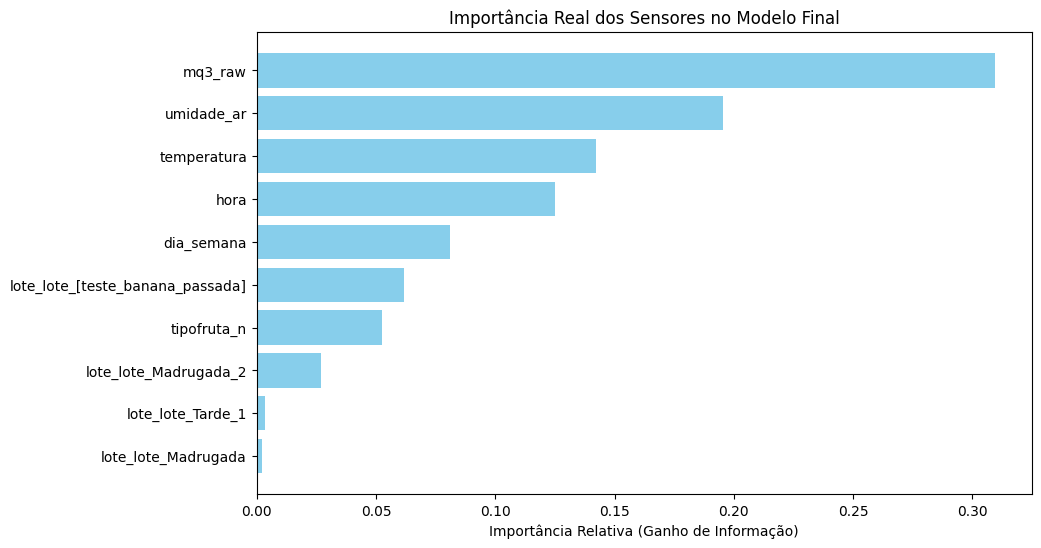

In [56]:
import numpy as np

# Extrai a importância direto do modelo treinado 
importances = modelo.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10,6))
plt.title('Importância Real dos Sensores no Modelo Final')
plt.barh(range(len(indices)), importances[indices], align='center', color='skyblue')

# Nomeia as barras com os nomes das colunas que o modelo usou
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Importância Relativa (Ganho de Informação)')

salvar_grafico("importancia_sensores_final")
plt.show()

In [57]:
import pandas as pd
from datetime import datetime

df_auditoria = df.copy()

data_hora = datetime.now().strftime("%d-%m-%Y_%H-%M")
nome_arquivo_csv = f"dataset_mestre_unificado_{data_hora}.csv"

try:
    df_auditoria.to_csv(nome_arquivo_csv, index=False, encoding='utf-8-sig', sep=';')
    
    print(f"{nome_arquivo_csv}")
    print(f"Total de registros: {len(df_auditoria)}")
    print(f"Arquivos unificados nesta extração: {df_auditoria['origem_arquivo'].unique()}")
    print("\nInstrução: Arquivo contém os dados ORIGINAIS unificados antes da limpeza para a IA, permitindo conferir a procedência de cada linha.")

except Exception as e:
    print(f" Erro ao exportar: {e}")

dataset_mestre_unificado_01-03-2026_20-41.csv
Total de registros: 133
Arquivos unificados nesta extração: ['banana.csv' 'banana_terra.csv' 'tomate.csv']

Instrução: Arquivo contém os dados ORIGINAIS unificados antes da limpeza para a IA, permitindo conferir a procedência de cada linha.
